# 3 — Máxima verosimilitud y SVD

📓 [Notebook de clase](../raw/3_regresion_lineal_maxima_verosimilitud_svd.ipynb) · ✏️ [Ejercicios](../exercises/3_regresion_lineal_maxima_verosimilitud_svd.ipynb) · 📕 *ESL* (Hastie, Tibshirani & Friedman) como referencia principal

> **TL;DR**
>
> - Máxima verosimilitud con errores normales iid **no es un método nuevo**:
>   devuelve exactamente el mismo $\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$
>   que cuadrados mínimos. Lo que agrega es una estimación de $\sigma^2$ y un
>   marco probabilístico donde el error tiene una distribución con nombre.
> - El estimador de $\sigma^2$ por verosimilitud divide la $RSS$ por $N$ y es
>   **sesgado** (tira bajo); el que se usa en la práctica divide por $N-p-1$ y
>   es insesgado. El numerador es el mismo.
> - La **SVD** descompone *cualquier* matriz $\textbf{X}$ de $N \times p$ como
>   $\textbf{X} = U D V^T$: $U$ y $V$ con columnas ortonormales, $D$ diagonal con
>   los **valores singulares** $d_1 \geq \dots \geq d_p \geq 0$. La cantidad de
>   $d_j$ distintos de cero es el **rango** de $\textbf{X}$.
> - Los valores singulares son la raíz cuadrada de los autovalores de
>   $\textbf{X}^T\textbf{X}$, porque $\textbf{X}^T\textbf{X} = V D^2 V^T$. Formar
>   ese producto **eleva al cuadrado el número de condición**: por eso los
>   algoritmos numéricos calculan la SVD trabajando directo sobre $\textbf{X}$.
> - En regresión, la SVD reescribe $\hat\beta = V D^{-1} U^T \textbf{y}$ (con la
>   pseudoinversa $D^{+}$ cuando $\textbf{X}$ no tiene rango completo) y la matriz
>   sombrero se reduce a $\textbf{H} = U U^T$. Multicolinealidad $=$ algún
>   $d_j \approx 0$ $=$ coeficientes inestables.

## 🗺️ Mapa de la clase

| Bloque de la clase | Celdas | Dónde lo explico |
|--------------------|--------|------------------|
| Regresión Lineal › Bibliografía: | 0 | §0 (nota al pie) |
| Repaso | 1–3 | §1 |
| Máxima Verosimilitud | 4–5 | §2 |
| Máxima Verosimilitud › Forma matricial | 6–8 | §2 (celdas 6–7) · §3 (celda 8) |
| Singular Value Decomposition (SVD) | 9–23 | §4 (celdas 9–17) · §5 (celdas 18–23) |
| Singular Value Decomposition (SVD) › Aplicaciones (en regresión lineal) | 24 | §6 |

Desglose fino, para volver de la explicación a la clase:

| Celdas | Contenido | Sección |
|--------|-----------|---------|
| 0 | Portada bibliográfica (Bishop cap. 3, ESL cap. 3, videos de SVD, MML) | §0 |
| 1–3 | Modelo lineal, ecuación normal, $Var(\hat\beta)$, $\hat\sigma^2$ | §1 |
| 4–5 | Principio de máxima verosimilitud, errores normales iid, log-verosimilitud | §2 |
| 6 | Forma matricial de la log-verosimilitud, MV $=$ mínimos cuadrados, $\hat\sigma^2$ | §2 |
| 7 | Tabla comparativa: cuadrados mínimos vs. máxima verosimilitud | §2 |
| 8 | Pregunta: ¿y si $\textbf{X}$ no tiene rango completo? Multicolinealidad | §3 |
| 9–14 | Definición de SVD, versión *thin*, rango, ortogonalidad, no unicidad, variantes | §4 |
| 15–17 | Código: `np.linalg.svd`, chequeo de ortogonalidad, reconstrucción | §4 |
| 18 | Los valores singulares como raíz de autovalores de $\textbf{X}^T\textbf{X}$ | §5 |
| 19 | Código: verificación numérica de eso | §5 |
| 20–21 | Interpretación geométrica: rotar – escalar – rotar | §5 |
| 22–23 | Cómo se obtiene la SVD y por qué no se calcula formando $\textbf{X}^T\textbf{X}$ | §5 |
| 24 | Aplicaciones en regresión: $\hat\beta = V D^{-1} U^T \textbf{y}$, matriz sombrero $\textbf{H} = U U^T$ | §6 |

Sobre la celda 0: es la portada bibliográfica de la clase. Además de Bishop
cap. 3 y ESL cap. 3 (los dos de siempre), aparecen dos referencias nuevas para
la SVD: una lista de videos de YouTube (la serie de Steve Brunton) y el libro
*Mathematics for Machine Learning* de Deisenroth, Faisal y Ong, cuyo capítulo 4
(§4.5 en particular) desarrolla la SVD con calma. No abre tema propio, así que no
tiene sección; las referencias puntuales van en el encabezado de cada sección.

Las dos figuras que la clase mostraba para la SVD están guardadas en
`src/figuras/` y se embeben directo en §4 y §5: `Reduced_Singular_Value_Decompositions.svg.png`
y `Singular-Value-Decomposition.svg.png`.


In [1]:
# Setup — estilo de gráficos (ver referencias/estilo_graficos.md) + imports comunes
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})


## 0. Notación y convenciones

📓 celda 0 · 📕 ESL §3.2 · 📘 Bishop §3.1.1

Esta clase mete notación nueva por dos lados: el vocabulario probabilístico de
máxima verosimilitud y todo el aparato de la SVD. Fijemos las piezas antes de
usarlas.

**Verosimilitud.** $\mathcal{L}(\theta)$ (leelo "ele caligráfica de theta": la
*verosimilitud*) es la probabilidad de haber observado los datos que tenés,
**leída como función de los parámetros** $\theta$, con los datos fijos. Es la
misma cuenta que una densidad de probabilidad, pero con los roles cambiados: en
una densidad, $\theta$ está fijo y barrés los datos posibles; en la
verosimilitud, los datos están fijos y barrés los $\theta$ posibles.
$\log \mathcal{L}(\theta)$ es la *log-verosimilitud*: como el logaritmo es
creciente, el $\theta$ que maximiza $\mathcal{L}$ es el mismo que maximiza
$\log \mathcal{L}$, y trabajar con la suma que da el logaritmo es mucho más
cómodo que con el producto.

**Qué es $\theta$ acá.** Para el modelo lineal con ruido gaussiano,
$\theta = (\beta, \sigma^2)$: los coeficientes $\beta$ **y** la varianza del
error $\sigma^2$. Es un cambio respecto de la clase 2, donde $\sigma^2$ era un
número que aparecía al final para hablar de $Var(\hat\beta)$; acá $\sigma^2$ es
un parámetro más que el método estima.

**$\sigma$ o $\sigma^2$.** La clase escribe la log-verosimilitud con un
"$-N \log \sigma$" (en $\sigma$) y después estima $\sigma^2$ (en $\sigma^2$). Es
la misma función reparametrizada: $-\tfrac{N}{2}\log(2\pi) - N\log\sigma$ es
idéntico a $-\tfrac{N}{2}\log(2\pi\sigma^2)$, porque
$N\log\sigma = \tfrac{N}{2}\log\sigma^2$. No son dos cosas distintas; es la
misma expresión escrita de dos maneras.

**Choque de notación con Bishop.** Si abrís Bishop §3.1.1 para ver esta misma
derivación, ojo: **Bishop llama $\beta$ a la precisión** $1/\sigma^2$ (un
escalar), no a los coeficientes. A los coeficientes Bishop les dice $\textbf{w}$,
a la matriz de diseño $\Phi$ y a las respuestas $\textbf{t}$. La cátedra usa la
notación de ESL. Tabla de traducción para esta clase:

| Concepto | ESL / cátedra | Bishop |
|---|---|---|
| Coeficientes | $\beta$ | $\textbf{w}$ |
| Matriz de diseño ($N \times (p{+}1)$) | $\textbf{X}$ | $\Phi$ |
| Vector de respuestas | $\textbf{y}$ | $\textbf{t}$ |
| Varianza del error | $\sigma^2$ | $\beta^{-1}$ (¡$\beta$ es la **precisión**!) |
| Cantidad de predictores | $p$ | $M-1$ (con $M$ funciones base) |

**Índices.** $x_i$ es el vector de atributos de la observación $i$-ésima, de
tamaño $p+1$ (arranca con un 1 para el intercepto); $y_i$ es un escalar.
$\textbf{X}$ (negrita mayúscula) es la matriz que apila esos $x_i^T$ como filas,
de $N \times (p+1)$; $\textbf{y}$ (negrita minúscula) es el vector columna de las
$N$ respuestas. Misma convención que la clase 2.

**SVD.** $\textbf{X} = U D V^T$. $U$ y $V$ tienen **columnas ortonormales**
(perpendiculares entre sí y de norma 1); $D$ es **diagonal** con entradas
$d_1 \geq d_2 \geq \dots \geq d_p \geq 0$, los *valores singulares*. $r$ es el
**rango** de $\textbf{X}$: la cantidad de $d_j$ estrictamente positivos. Todo el
detalle —tamaños, versión *thin*, qué significa cada matriz— está en §4.


## 1. Repaso: dónde quedamos con cuadrados mínimos

📓 celdas 1–3 · 📕 ESL §3.2 · 📘 Bishop §3.1

### La idea en criollo

Antes de arrancar con lo nuevo, la clase repasa el final de la clase 2 en tres
celdas. Pensalo como el "resumen de la anterior" de una serie: el modelo lineal,
la fórmula cerrada de los coeficientes, y las dos cantidades estadísticas que
salen de ahí (la varianza de esos coeficientes y una estimación de cuánto ruido
tienen los datos).

> **Dónde se rompe la analogía.** Un "resumen de la anterior" te cuenta lo que
> pasó y listo. Acá el repaso tiene una intención: la celda 2 remata con
> "*prácticamente ninguna hipótesis sobre los datos, más allá de que
> $\textbf{X}$ tiene rango completo*", y esa frase es el gancho de toda la
> clase. Todo lo que viene —máxima verosimilitud primero, SVD después— gira
> alrededor de qué pasa cuando esa única hipótesis falla.

### Formalizándolo

**El modelo (celda 1).** La regresión lineal asume que la relación entre el
vector de entradas $X^T = (X_1, \dots, X_p)$ y la salida $Y$ se aproxima bien
con una función lineal:

$$f(X) = \beta_0 + \sum_{j=1}^{p} X_j \beta_j = X^T\beta$$

donde en la forma compacta $X$ es un vector de $p+1$ componentes que arranca con
un 1, y $\beta = (\beta_0, \dots, \beta_p)$ son los coeficientes a estimar.
Nada nuevo respecto de la clase 2 §1.

**Cuadrados mínimos (celda 2).** Se elige $\beta$ minimizando la suma de
residuos al cuadrado:

$$RSS(\beta) = \|\textbf{y} - \textbf{X}\beta\|^2 = (\textbf{y} - \textbf{X}\beta)^T(\textbf{y} - \textbf{X}\beta)$$

y la solución, si $\textbf{X}$ tiene rango columna completo, es la **ecuación
normal**:

$$\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}, \qquad \hat{\textbf{y}} = \textbf{X}\hat\beta = \textbf{X}(\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$$

La derivación completa —abrir el binomio, usar que
$\textbf{y}^T\textbf{X}\beta$ es un escalar y por lo tanto igual a su
transpuesta, derivar la cuadrática, chequear con la segunda derivada que el
punto crítico es un mínimo— está en la clase 2 §2. Acá se da por sabida.

**Varianza y estimación del ruido (celda 3).** Si se agrega el supuesto
$Var(\epsilon) = \sigma^2 I$ (todos los errores con la misma varianza $\sigma^2$
y no correlacionados entre sí — $I$ es la matriz identidad):

$$Var(\hat\beta) = \sigma^2(\textbf{X}^T\textbf{X})^{-1}$$

y $\sigma^2$ se estima con

$$\hat\sigma^2 = \frac{1}{N-p-1}\sum_{i=1}^{N}(y_i - \hat y_i)^2$$

El denominador es $N-p-1$ (los **grados de libertad** residuales), no $N$,
porque ya se gastaron $p+1$ grados de libertad estimando los $p+1$ coeficientes.
En §2 vamos a ver de dónde sale ese $N-p-1$ y por qué máxima verosimilitud, si
la dejás sola, te devuelve un $N$ en ese lugar.

### ¿Por qué nos importa?

Porque esta clase no reemplaza nada de la anterior: la **amplía**. La ecuación
normal sigue siendo la solución. Lo que cambia es que vamos a llegar a ella por
un segundo camino (verosimilitud) y vamos a tener una herramienta nueva (SVD)
para el caso exacto que la clase 2 dejó afuera: $\textbf{X}$ sin rango completo.


In [2]:
# prostate.data: 8 predictores (lcavol ... pgg45), respuesta lpsa, columna 'train'.
# Este X y este beta_hat son los que vamos a reusar en toda la clase.
df = pd.read_csv(Path("../../datasets/prostate.data"), sep="\t").drop(columns="Unnamed: 0", errors="ignore")
pred = ["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]

X = np.column_stack([np.ones(len(df)), df[pred].to_numpy()])   # columna de 1s + predictores
y = df["lpsa"].to_numpy()

beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)               # ecuación normal, sin invertir nada
resid = y - X @ beta_hat
N, p = X.shape[0], X.shape[1] - 1
sigma2_hat = resid @ resid / (N - p - 1)                       # divide por N - p - 1
var_beta = sigma2_hat * np.linalg.inv(X.T @ X)                 # sigma^2 (X^T X)^-1

print(f"N={N}, p={p}")
print("beta_hat:", beta_hat.round(4))
print("sigma2_hat:", round(sigma2_hat, 4))


N=97, p=8
beta_hat: [ 0.1816  0.5643  0.622  -0.0212  0.0967  0.7617 -0.1061  0.0492  0.0045]
sigma2_hat: 0.4893


Este `X` y este `beta_hat` son los que vas a reusar en todo el ejercicio de la
clase. Los coeficientes de arriba tienen que coincidir (salvo redondeo) con la
**Tabla 3.2 de ESL**, que reporta el ajuste de mínimos cuadrados sobre este
mismo dataset — y coinciden.

### ⚠️ Confusión típica

Pensar que "asumir $Var(\epsilon) = \sigma^2 I$" es parte de cuadrados mínimos.
No: la fórmula $\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$
no necesita ningún supuesto sobre el ruido, solo rango completo. Los supuestos
sobre $\epsilon$ hacen falta recién para decir algo sobre $Var(\hat\beta)$,
sesgo, o —como vamos a ver ya— para plantear la verosimilitud.


## 2. Máxima verosimilitud: otro camino al mismo $\hat\beta$

📓 celdas 4–7 · 📕 ESL §2.6 (máxima verosimilitud y mínimos cuadrados) · 📘 Bishop §3.1.1

### La idea en criollo

Cambiá la pregunta. Cuadrados mínimos pregunta: *"¿qué $\beta$ hace que mis
predicciones queden lo más cerca posible de los datos?"*. Máxima verosimilitud
pregunta: *"si el mundo funcionara con este $\beta$ y este nivel de ruido,
¿qué tan probable sería haber visto exactamente los datos que vi?"*, y elige el
$\beta$ que hace esa probabilidad lo más alta posible.

Es como un detective que tiene varias hipótesis sobre cómo pasó un hecho. No se
queda con la que "explica cómodo" los indicios: se queda con la que hace que el
conjunto completo de indicios sea lo **menos sorprendente** posible.

> **Dónde se rompe la analogía.** El detective compara un puñado de hipótesis
> discretas ("fue A", "fue B"). Acá el espacio de hipótesis es continuo —todos
> los $(\beta, \sigma^2)$ posibles— y no las comparás de a una: escribís la
> probabilidad como función de esos parámetros y la maximizás con cálculo. Y hay
> una hipótesis de fondo que el detective no necesita: **la forma de la
> distribución del ruido**. Sin asumir que $\epsilon$ es normal, la cuenta de
> abajo no arranca.

### Formalizándolo

**El principio (celda 4).** Dado el modelo $Y = f_\theta(X) + \epsilon$, para un
conjunto de datos $(\textbf{X}, \textbf{y})$ la **verosimilitud** es la
probabilidad conjunta de las respuestas observadas dadas las entradas y los
parámetros:

$$\mathcal{L}(\theta) = P(\textbf{y}\mid\textbf{X}, \theta) = P(y_1, \dots, y_N \mid x_1, \dots, x_N, \theta)$$

Si las observaciones son **independientes** entre sí, esa probabilidad conjunta
se factoriza en el producto de las individuales:

$$\mathcal{L}(\theta) = \prod_{i=1}^{N} P(y_i \mid x_i, \theta)$$

y tomando logaritmo, el producto se vuelve suma:

$$\log \mathcal{L}(\theta) = \sum_{i=1}^{N} \log P(y_i \mid x_i, \theta)$$

Hasta acá no hay ningún supuesto sobre *qué forma* tiene $P(y_i \mid x_i,\theta)$.

**El supuesto gaussiano (celda 5).** Se asume que los errores son independientes
e idénticamente distribuidos (**iid**) y normales:
$\epsilon \sim \mathcal{N}(0, \sigma^2)$. Entonces, dado $x_i$, la respuesta
$y_i$ es normal centrada en la predicción del modelo:

$$P(y_i \mid x_i, \theta) = \mathcal{N}(f_\theta(x_i), \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\, e^{-\frac{(y_i - f_\theta(x_i))^2}{2\sigma^2}}$$

Metiendo esa densidad en la suma del logaritmo, y usando que
$\log\big(\tfrac{1}{\sqrt{2\pi\sigma^2}} e^{-a}\big) = -\tfrac{1}{2}\log(2\pi) - \log\sigma - a$:

$$\log \mathcal{L}(\theta, \sigma^2) = -\frac{N}{2}\log(2\pi) - N\log\sigma - \frac{1}{2\sigma^2}\sum_{i=1}^{N}(y_i - f_\theta(x_i))^2$$

Para el modelo lineal, $f_\theta(x_i) = x_i^T\beta$, así que la suma del final es
$\sum_i (y_i - x_i^T\beta)^2$.

**Forma matricial (celda 6).** Esa suma de cuadrados es, otra vez, una norma:

$$\log \mathcal{L}(\beta, \sigma^2) = -\frac{N}{2}\log(2\pi) - N\log\sigma - \frac{1}{2\sigma^2}(\textbf{y} - \textbf{X}\beta)^T(\textbf{y} - \textbf{X}\beta)$$

Ahora viene el punto de toda la sección. **Maximizar respecto de $\beta$:** de
los tres términos, los dos primeros no dependen de $\beta$; son constantes para
esta maximización. Solo importa el tercero,
$-\tfrac{1}{2\sigma^2}(\textbf{y}-\textbf{X}\beta)^T(\textbf{y}-\textbf{X}\beta)$.
Y como $\sigma^2 > 0$, el factor $-\tfrac{1}{2\sigma^2}$ es una constante
**negativa**: maximizar "menos una constante positiva por $RSS(\beta)$" es
exactamente lo mismo que **minimizar $RSS(\beta)$**. Entonces:

$$\hat\beta_{\text{MV}} = \arg\max_\beta \log\mathcal{L}(\beta,\sigma^2) = \arg\min_\beta RSS(\beta) = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$$

El $\hat\beta$ de máxima verosimilitud **es** el de cuadrados mínimos. No se
parece: es el mismo, con la misma fórmula. Y notá que esto no depende del valor
de $\sigma^2$: sale igual para cualquier $\sigma^2 > 0$.

**Estimar $\sigma^2$ (celda 6).** Acá la clase da el resultado de un salto. Lo
completamos. Sustituimos $\hat\beta$ en la log-verosimilitud y llamamos
$S = (\textbf{y}-\textbf{X}\hat\beta)^T(\textbf{y}-\textbf{X}\hat\beta)$ a la
$RSS$ ya minimizada, que ahora es un **número fijo**. Queda una función de
$\sigma$ sola:

$$\ell(\sigma) = -\frac{N}{2}\log(2\pi) - N\log\sigma - \frac{S}{2\sigma^2}$$

Derivamos respecto de $\sigma$, término a término. La derivada de $-N\log\sigma$
es $-N/\sigma$. La de $-\tfrac{S}{2}\sigma^{-2}$ es
$-\tfrac{S}{2}\cdot(-2)\sigma^{-3} = S/\sigma^3$:

$$\frac{d\ell}{d\sigma} = -\frac{N}{\sigma} + \frac{S}{\sigma^3}$$

Igualamos a cero y multiplicamos por $\sigma^3$ (que es positivo, no cambia la
ecuación):

$$-N\sigma^2 + S = 0 \quad\Longrightarrow\quad \hat\sigma^2_{\text{MV}} = \frac{S}{N} = \frac{1}{N}(\textbf{y} - \textbf{X}\hat\beta)^T(\textbf{y} - \textbf{X}\hat\beta)$$

**¿Es un máximo?** Derivada primera cero solo dice "punto crítico". La segunda
derivada es
$\tfrac{d^2\ell}{d\sigma^2} = \tfrac{N}{\sigma^2} - \tfrac{3S}{\sigma^4}$.
Evaluada en $\sigma^2 = S/N$:
$\tfrac{N}{S/N} - \tfrac{3S}{(S/N)^2} = \tfrac{N^2}{S} - \tfrac{3N^2}{S} = -\tfrac{2N^2}{S} < 0$.
Negativa, así que es un máximo. Ahora sí la cuenta está cerrada.

**Sesgado (celda 6).** El estimador $\hat\sigma^2_{\text{MV}} = S/N$ es
**sesgado**, y la clase lo dice pero no explica por qué. El motivo: se puede
mostrar que $E[S] = (N - p - 1)\,\sigma^2$. En una línea, el vector de residuos
es $\textbf{y} - \hat{\textbf{y}} = (I - \textbf{H})\textbf{y} = (I-\textbf{H})\epsilon$
(usando que $(I-\textbf{H})\textbf{X} = 0$, porque $\textbf{H}$ proyecta sobre el
espacio de columnas de $\textbf{X}$ y deja fijo lo que ya está ahí), y entonces

$$E[S] = E[\epsilon^T(I-\textbf{H})\epsilon] = \sigma^2\,\text{tr}(I - \textbf{H}) = \sigma^2\big(N - \text{tr}\,\textbf{H}\big) = \sigma^2(N - p - 1)$$

porque $\text{tr}\,\textbf{H} = p+1$ (la traza de la matriz sombrero es el
número de columnas independientes de $\textbf{X}$ — lo vas a ver clarísimo en §6,
donde $\textbf{H} = UU^T$ y $\text{tr}(UU^T) = \text{tr}(U^TU) = \text{tr}(I_{p+1}) = p+1$).
Por lo tanto
$E[\hat\sigma^2_{\text{MV}}] = \tfrac{N-p-1}{N}\sigma^2 < \sigma^2$: subestima
siempre. Dividir por $N - p - 1$ en lugar de por $N$ corrige exactamente ese
factor y da el estimador insesgado de la celda 3 y de la clase 2.

**La tabla comparativa (celda 7).** La clase cierra con una tabla larga. Lo que
hay que llevarse:

| | Cuadrados mínimos | Máxima verosimilitud |
|---|---|---|
| Qué optimiza | $\min_\beta \sum (y_i - f(x_i,\beta))^2$ | $\max_\beta \prod P(y_i\mid x_i,\beta)$ |
| Supuestos sobre el error | ninguno (sirve para cualquier $f$) | distribución conocida (acá, normal) |
| Qué te da de más | — | una estimación de $\sigma^2$ y el marco probabilístico |
| Para el modelo lineal + error normal iid | $\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$ | **el mismo** $\hat\beta$ |

Los dos son sensibles a *outliers*, porque los dos terminan penalizando el
error al cuadrado (en máxima verosimilitud, el cuadrado aparece por asumir
normalidad: si asumieras otra distribución de cola más pesada, la penalización
cambiaría).

### ¿Por qué nos importa?

Por dos razones. La primera, conceptual: cuadrados mínimos parecía una elección
medio arbitraria ("¿por qué al cuadrado y no en valor absoluto?"). Máxima
verosimilitud le da una **justificación probabilística**: si creés que el ruido
es gaussiano, minimizar el error cuadrático no es un capricho, es la respuesta
óptima. La segunda, práctica: el marco de verosimilitud se **generaliza** a
modelos donde no hay solución cerrada (regresión logística, GLM, casi todo lo
que viene después). Regresión lineal es el caso donde ese marco general
coincide con la cuenta que ya sabías.


In [3]:
beta_ls, *_ = np.linalg.lstsq(X, y, rcond=None)          # cuadrados mínimos
# "máxima verosimilitud" para beta es el mismo problema: minimizar RSS
beta_mv = beta_ls
assert np.allclose(beta_ls, beta_mv)                     # no "casi": idéntico

S = np.sum((y - X @ beta_mv) ** 2)                       # RSS minimizada
sigma2_mv        = S / N                                 # el que sale de la verosimilitud (sesgado)
sigma2_insesgado = S / (N - p - 1)                       # el que se usa

print("sigma2_mv (sesgado):       ", round(sigma2_mv, 4))
print("sigma2_insesgado:          ", round(sigma2_insesgado, 4))
print("sigma2_mv / sigma2_insesgado =", round(sigma2_mv / sigma2_insesgado, 4), "(siempre < 1)")


sigma2_mv (sesgado):        0.4439
sigma2_insesgado:           0.4893
sigma2_mv / sigma2_insesgado = 0.9072 (siempre < 1)


### ⚠️ Confusión típica

Creer que "máxima verosimilitud" y "cuadrados mínimos" son dos estimadores
distintos que *casualmente* dan parecido. Para el modelo lineal con error
normal iid dan **exactamente** lo mismo para $\beta$ —no hay diferencia numérica
ninguna—, como confirma el `assert` de arriba. La única diferencia real está en
$\sigma^2$: la verosimilitud, cruda, divide por $N$; la práctica estadística
divide por $N-p-1$.

Segunda trampa: pensar que la normalidad se usa para estimar $\beta$. No se usa.
$\hat\beta$ sale igual asumiendo cualquier distribución simétrica de media cero;
lo que la normalidad te compra es la forma específica de $\hat\sigma^2$ y toda
la maquinaria de inferencia ($Z$-scores, $F$) de la clase 2 §5.


## 3. La pregunta que rompe todo: ¿y si $\textbf{X}$ no tiene rango completo?

📓 celda 8 · 📕 ESL §3.4 · 📘 Bishop §3.1.4

### La idea en criollo

Toda la clase 2 y las dos primeras secciones de esta se apoyaron en una muleta:
"$\textbf{X}$ tiene rango columna completo, así que $\textbf{X}^T\textbf{X}$ es
invertible". La celda 8 es una sola línea que patea esa muleta:

> *¿Qué pasa si $\textbf{X}$ no tiene rango completo? ¿Qué pasa si hay
> predictores correlacionados o si hay multicolinealidad?*

Pensalo así: pedís que te den la receta de una torta como combinación de
ingredientes, pero en la lista de ingredientes pusiste "harina", "harina en
gramos" y "harina en tazas". Son la misma cosa expresada distinto. Hay
infinitas maneras de repartir "cuánta harina" entre esas tres columnas que dan
la misma torta. No hay **una** respuesta.

> **Dónde se rompe la analogía.** En la torta, las tres columnas de harina son
> *exactamente* proporcionales: dependencia lineal perfecta, rango deficiente
> de verdad. En datos reales casi nunca tenés eso; tenés columnas *casi*
> dependientes (dos predictores con correlación 0.99). Ahí
> $\textbf{X}^T\textbf{X}$ técnicamente sí es invertible, pero "por poco", y esa
> inversión amplifica el ruido de forma brutal. El problema práctico no es
> "rango deficiente" (raro), es "**cerca** de rango deficiente" (común).

### Formalizándolo

**Rango deficiente exacto.** Si una columna de $\textbf{X}$ es combinación
lineal de las otras, existe un vector $v \neq 0$ con $\textbf{X}v = 0$.
Entonces $\textbf{X}^T\textbf{X}\,v = \textbf{X}^T(\textbf{X}v) = 0$: la matriz
$\textbf{X}^T\textbf{X}$ manda un vector no nulo al cero, así que **no es
invertible**. La ecuación normal $\textbf{X}^T\textbf{X}\hat\beta = \textbf{X}^T\textbf{y}$
sigue teniendo solución, pero **infinitas**: si $\hat\beta$ es una, entonces
$\hat\beta + v$ también lo es, y da el mismo $\hat{\textbf{y}}$ y el mismo $RSS$.
La geometría no se rompe (la proyección $\hat{\textbf{y}}$ sigue siendo única);
lo que se rompe es la unicidad de los coeficientes.

**Multicolinealidad (rango casi deficiente).** Cuando las columnas están muy
correlacionadas sin ser exactamente dependientes, $\textbf{X}^T\textbf{X}$ es
invertible pero **mal condicionada**: su autovalor más chico es diminuto.
Como $Var(\hat\beta) = \sigma^2(\textbf{X}^T\textbf{X})^{-1}$, ese autovalor
chico se invierte a un número gigante y las varianzas de los coeficientes
explotan. Síntoma clásico: agregás una observación, o sacás una, y los
$\hat\beta_j$ cambian de signo y de orden de magnitud, aunque las predicciones
$\hat{\textbf{y}}$ casi no se muevan.

### ¿Por qué nos importa?

Porque es un problema **real y frecuente**, no una patología de examen: cuando
tenés muchos predictores medidos sobre el mismo fenómeno, es normal que estén
correlacionados. Y la respuesta a "¿qué hacemos?" abre dos ramas grandes de la
materia:

- **Diagnosticar y resolver con álgebra:** la SVD, que es el resto de esta
  clase. Te dice exactamente *qué* dirección de $\textbf{X}$ está casi
  colapsada (los $d_j$ chicos) y te da una forma de estimar $\hat\beta$ que no
  se vuelve loca (la pseudoinversa, §6).
- **Resolver penalizando:** Ridge, Lasso y compañía (ESL §3.4), la próxima
  clase. Ridge le suma $\lambda I$ a $\textbf{X}^T\textbf{X}$ antes de invertir,
  y eso levanta el autovalor chico y estabiliza todo. No es casualidad que la
  SVD también sea la herramienta con la que ESL analiza Ridge.


In [4]:
rng = np.random.default_rng(0)

Xb = np.column_stack([np.ones(100), rng.normal(size=(100, 2))])    # X bien portada
gemela = Xb[:, 1] + 1e-4 * rng.normal(size=100)                    # casi igual a la columna 1
Xc = np.column_stack([Xb, gemela])                                 # X con multicolinealidad

conds = {}
for M, nombre in [(Xb, "bien portada"), (Xc, "colineal")]:
    conds[nombre] = np.linalg.cond(M.T @ M)
    print(f"{nombre:>13}:  cond(X^T X) = {conds[nombre]:.1e}")

y_sim = Xb @ np.array([1.0, 2.0, -1.0]) + rng.normal(scale=0.1, size=100)

# mismo modelo, quitando una sola observación cada vez: mirá cuánto se mueven los coefs
filas = []
for drop in (None, 0, 1, 2):
    idx = np.ones(100, bool)
    if drop is not None:
        idx[drop] = False
    b, *_ = np.linalg.lstsq(Xc[idx], y_sim[idx], rcond=None)
    filas.append({"drop": drop, "b1": b[1], "b3": b[3], "b1+b3": b[1] + b[3]})
    print(f"  drop={str(drop):>4}:  b1={b[1]:+8.2f}  b3={b[3]:+8.2f}   (b1+b3={b[1]+b[3]:+.3f})")


 bien portada:  cond(X^T X) = 1.4e+00
     colineal:  cond(X^T X) = 3.2e+08
  drop=None:  b1=  -32.49  b3=  +34.48   (b1+b3=+1.986)
  drop=   0:  b1=  -37.29  b3=  +39.27   (b1+b3=+1.986)
  drop=   1:  b1=  -35.15  b3=  +37.14   (b1+b3=+1.985)
  drop=   2:  b1=  -41.04  b3=  +43.02   (b1+b3=+1.986)


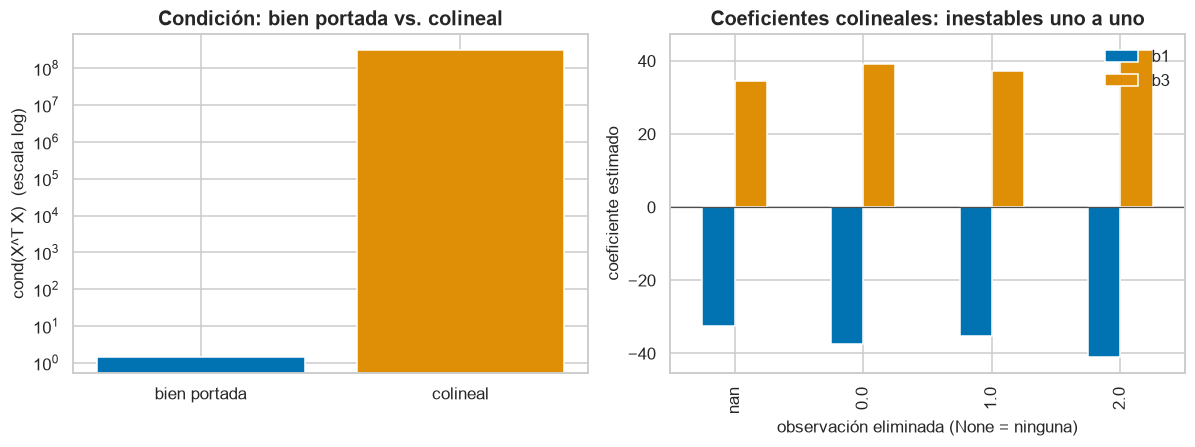

In [5]:
# El número de condición salta órdenes de magnitud; los coeficientes individuales
# saltan de signo y magnitud, pero su suma (el efecto conjunto real) queda estable.
tabla = pd.DataFrame(filas).set_index("drop")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(conds.keys(), conds.values(), color=sns.color_palette("colorblind")[:2])
axes[0].set_yscale("log")
axes[0].set_ylabel("cond(X^T X)  (escala log)")
axes[0].set_title("Condición: bien portada vs. colineal")

tabla[["b1", "b3"]].plot(kind="bar", ax=axes[1])
axes[1].axhline(0, color="0.3", linewidth=0.8)
axes[1].set_xlabel("observación eliminada (None = ninguna)")
axes[1].set_ylabel("coeficiente estimado")
axes[1].set_title("Coeficientes colineales: inestables uno a uno")

fig.tight_layout()
plt.show()


El número de condición de $\textbf{X}^T\textbf{X}$ salta varios órdenes de
magnitud al agregar la columna casi redundante (panel izquierdo). Y aunque
sacar **una sola** observación casi no cambia las predicciones, los
coeficientes $b_1$ y $b_3$ de las dos columnas gemelas pegan saltos enormes y
de signo arbitrario (panel derecho): lo único estable es su **suma** (el
efecto "real", que el modelo no sabe cómo repartir).

### ⚠️ Confusión típica

Pensar que multicolinealidad "arruina el modelo". No arruina las
**predicciones**: $\hat{\textbf{y}}$ puede seguir siendo excelente. Lo que
arruina es la **interpretación** de los coeficientes individuales y su
estabilidad. Si solo te importa predecir, a veces podés convivir con ella; si te
importa decir "esta variable aporta tanto", tenés un problema.

### ❓ La pregunta que quedó abierta

La celda 8 pregunta y sigue de largo sin responder. La respuesta corta es: **si
$\textbf{X}$ no tiene rango completo, no hay un único $\hat\beta$** (hay un
subespacio entero de soluciones con el mismo $RSS$), y **si está cerca de no
tenerlo, el $\hat\beta$ único que existe es numéricamente basura** (varianza
enorme, súper sensible a los datos). Las secciones 4 a 6 construyen la
herramienta —SVD— que te deja ver esto con precisión y te da una salida: la
pseudoinversa de Moore–Penrose, que entre todas las soluciones elige la de
norma mínima.


## 4. SVD: qué es y por qué "cualquier matriz"

📓 celdas 9–17 · 📕 ESL §3.4.1 · Mathematics for Machine Learning §4.5

### La idea en criollo

La descomposición en valores singulares te dice que **toda** transformación
lineal, por rara que sea, es en el fondo una secuencia de tres movimientos
simples: rotás, estirás cada eje por su cuenta, y volvés a rotar. La matriz
$\textbf{X}$ cruda mezcla todo eso; la SVD lo separa en tres matrices donde cada
una hace un solo trabajo.

La frase de la clase, *"the SVD is like a mathematical Swiss Army knife"* (y la
otra, que la llaman *"el teorema fundamental del álgebra lineal"*), apunta a que
con esta única descomposición resolvés rango, inversa, proyección, mínimos
cuadrados, compresión y PCA. Una herramienta, muchos usos.

> **Dónde se rompe la analogía.** "Rotar – estirar – rotar" es literal y exacto
> cuando $\textbf{X}$ es cuadrada e inversible. Cuando $\textbf{X}$ es
> $N \times p$ con $N > p$ (nuestro caso), el segundo "rotar" —la matriz $U$— no
> es una rotación de todo $\mathbb{R}^N$: es un encaje isométrico de
> $\mathbb{R}^p$ dentro de $\mathbb{R}^N$ (mete el espacio chico adentro del
> grande sin deformarlo). Y las "rotaciones" pueden en realidad incluir una
> reflexión. La imagen sirve para la intuición; los detalles de dimensión hay
> que mirarlos aparte.

### Formalizándolo

**La descomposición (celda 9).** Cualquier matriz $\textbf{X}$ de $N \times p$
se escribe como

$$\textbf{X} = U D V^T$$

Vamos a usar la versión **thin** (reducida), que asume $N \geq p$ —más
observaciones que atributos, el caso habitual—. En esa versión:

- $U$ es de $N \times p$ con **columnas ortonormales**: $U^T U = I_p$
  (la identidad de $p \times p$). Leelo "U": es la matriz de vectores
  singulares izquierdos.
- $D$ es **diagonal** de $p \times p$, con entradas
  $d_1 \geq d_2 \geq \dots \geq d_p \geq 0$ en la diagonal. Esos $d_j$ son los
  **valores singulares** de $\textbf{X}$.
- $V$ es **ortogonal** de $p \times p$: $V^T V = V V^T = I_p$. Leelo "V": la
  matriz de vectores singulares derechos. Como es cuadrada y ortogonal, su
  inversa es su transpuesta.

**Rango y valores singulares (celda 10).** La cantidad de $d_j$ **no nulos** es
el **rango** $r$ de $\textbf{X}$:

- Si algún $d_j = 0$, entonces $\textbf{X}$ **no tiene rango completo**.
- Las primeras $r$ columnas de $U$ son una base ortonormal del **espacio
  columna** de $\textbf{X}$ (todo lo que $\textbf{X}$ puede producir).
- Las primeras $r$ columnas de $V$ son una base del **espacio fila**; las
  $p - r$ restantes son una base del **núcleo** de $\textbf{X}$: las direcciones
  $v$ con $\textbf{X}v = 0$, que la matriz aplasta a cero. Justo el vector $v$
  de la §3.

**Ortogonal vs. semi-ortogonal (celda 10).** Una matriz cuadrada $Q$ es
*ortogonal* si $Q^T Q = Q Q^T = I$; entonces $Q^{-1} = Q^T$. Si la matriz no es
cuadrada esto no puede pasar del todo: para $U$ de $N \times p$ con $N > p$ vale
$U^T U = I_p$, pero $U U^T \neq I_N$. Esa matriz $U U^T$ **no es la identidad**:
es el **proyector ortogonal sobre el espacio columna de $U$** (que es el de
$\textbf{X}$). Guardate este dato: en §6 vamos a reencontrar $U U^T$ como la
matriz sombrero $\textbf{H}$ de la clase 2.

**No unicidad (celdas 11, 14).** Dos aclaraciones:

1. La *formulación* no es única: además de la *thin*, está la *full* ($U$ de
   $N \times N$, $V$ de $p \times p$, $D$ de $N \times p$), la *compact* (se
   tiran los $d_j = 0$) y la *truncated* (se queda con los $t$ mayores). La
   figura de la clase (abajo) las compara.
2. Incluso fijada la formulación, la descomposición no es única: si hay valores
   singulares repetidos, o si un $d_j = 0$, hay libertad en la elección de las
   columnas correspondientes de $U$ y $V$ (y siempre podés cambiarle el signo a
   una columna de $U$ y a la de $V$ a la vez).

**Las cuatro variantes (celda 13).**

- *Full SVD*: $U$ y $V$ completas y cuadradas, $D$ rectangular.
- *Thin SVD*: se eliminan las columnas de $U$ que no se aparean con filas de
  $V^T$ (las que multiplicarían por ceros de $D$). Es la que usamos.
- *Compact SVD*: se eliminan además los $d_j = 0$ y las columnas/filas
  asociadas en $U$ y $V^T$. Queda todo de tamaño $r$.
- *Truncated SVD*: te quedás con los $t$ mayores valores singulares y tirás el
  resto, aunque no sean cero. Ya no reconstruye $\textbf{X}$ exacta: da la
  **mejor aproximación de rango $t$**. Es la base de la compresión y de PCA, y
  reaparece en el ejercicio como forma de domar la multicolinealidad.


#### 🖼️ La figura de la clase

![Las cuatro formulaciones de la SVD: full, thin, compact y truncated](../../figuras/Reduced_Singular_Value_Decompositions.svg.png)

Es el diagrama de bloques que compara las cuatro variantes de arriba. En cada
fila hay cuatro rectángulos alineados que representan la ecuación
$\textbf{X} = U D V^T$. Fijate en las proporciones, no en los colores: en la
fila *thin* (la que usamos), $\textbf{X}$ es un rectángulo alto y angosto
($N$ filas, $p$ columnas), $U$ tiene ese mismo alto pero es igual de angosto
($N \times p$), y $D$ y $V^T$ son cuadraditos chicos ($p \times p$) — $D$ con
la diagonal marcada y ceros afuera. La idea visual central: toda la "altura"
$N$ vive en $U$, mientras que $D$ y $V^T$ son objetos chicos de tamaño $p$. Por
eso la *thin* es barata cuando $N$ es enorme: nunca armás nada de tamaño
$N \times N$. Compará esa fila con la *full* (arriba, $U$ cuadrada de
$N \times N$) para ver de dónde sale el ahorro.


In [6]:
X_ej = np.array([[1., 1, 1], [0, 1, 1], [1, 2, 2], [1, 3, 3]])   # la 3ra col = la 2da: rango 2
U, d, Vt = np.linalg.svd(X_ej, full_matrices=False)              # d es el VECTOR de valores singulares

print("rango:", np.sum(d > 1e-12), " (de", X_ej.shape[1], "columnas)")
print("d:", d.round(3))                                        # el último ~ 0
print("U^T U ≈ I:", np.allclose(U.T @ U, np.eye(U.shape[1])))
print("V V^T ≈ I:", np.allclose(Vt.T @ Vt, np.eye(Vt.shape[0])))
print("reconstruye:", np.allclose(U @ np.diag(d) @ Vt, X_ej))
print("U U^T ≠ I:", not np.allclose(U @ U.T, np.eye(U.shape[0])))  # proyector, no identidad


rango: 2  (de 3 columnas)
d: [5.696 0.745 0.   ]
U^T U ≈ I: True
V V^T ≈ I: True
reconstruye: True
U U^T ≠ I: True


`np.linalg.svd` devuelve `d` como vector (los valores de la diagonal), no como
matriz: para reconstruir hay que armar `np.diag(d)`. Con `full_matrices=False`
pedís la versión *thin*. El tercer retorno ya es $V^T$, no $V$ — cuidado con eso
al escribir $\hat\beta = V D^{-1} U^T \textbf{y}$ en §6.

### ⚠️ Confusión típica

Tres clásicas con `np.linalg.svd`:

1. Tratar el segundo retorno como una matriz. Es un **vector** de $p$ números.
2. Olvidar que el tercer retorno es $V^T$ y no $V$. Si tu fórmula pide $V$,
   tenés que transponer (`Vt.T`).
3. Pedir `full_matrices=True` (el default) y después sorprenderte de que $U$ sea
   $N \times N$ y no cierre con las dimensiones de $D$. Para regresión querés
   casi siempre `full_matrices=False`.


## 5. Los valores singulares: de dónde salen y qué significan

📓 celdas 18–23 · 📕 ESL §3.4.1 · Mathematics for Machine Learning §4.5

### La idea en criollo

Un valor singular $d_j$ mide **cuánto estira $\textbf{X}$ en una dirección
particular**. El más grande, $d_1$, es el factor de estiramiento máximo sobre
todo vector de entrada; el más chico, $d_p$, el mínimo. Si $d_p = 0$, hay una
dirección que $\textbf{X}$ manda entera al cero: perdiste una dimensión. Si
$d_p$ es diminuto pero no cero, casi la perdés, y ahí está la multicolinealidad
de la §3, ahora con un número que la cuantifica.

> **Dónde se rompe la analogía.** "Estirar en una dirección" sugiere que
> $\textbf{X}$ actúa sobre las direcciones de siempre (los ejes $X_1, X_2,
> \dots$). No: estira a lo largo de las direcciones de $V$ (las columnas
> $v_j$), que son una base **rotada** elegida por la propia matriz. En los ejes
> originales, $\textbf{X}$ mezcla estiramientos y rotaciones y no se ve limpio;
> recién en la base de $V$ cada dirección tiene su factor único $d_j$.

### Formalizándolo

**Qué son los valores singulares (celda 18).** *Los valores singulares son la
raíz cuadrada de los autovalores de $\textbf{X}^T\textbf{X}$.* La cuenta que lo
prueba es corta. Partí de $\textbf{X} = U D V^T$ y armá $\textbf{X}^T\textbf{X}$:

$$\textbf{X}^T\textbf{X} = (U D V^T)^T (U D V^T) = V D U^T U D V^T = V D\,(U^T U)\,D\,V^T = V D^2 V^T$$

donde usamos $(ABC)^T = C^T B^T A^T$, que $D^T = D$ por ser diagonal, y
$U^T U = I$ por la ortonormalidad de las columnas de $U$. La expresión final,
$\textbf{X}^T\textbf{X} = V D^2 V^T$ con $V$ ortogonal y $D^2$ diagonal, **es una
descomposición en autovectores** de $\textbf{X}^T\textbf{X}$:

- las columnas de $V$ son los **autovectores** de $\textbf{X}^T\textbf{X}$;
- los **autovalores** son los $d_j^2$ (las entradas de $D^2$).

Por lo tanto $d_j = \sqrt{\lambda_j}$, con $\lambda_j$ el $j$-ésimo autovalor de
$\textbf{X}^T\textbf{X}$. Y esos $\lambda_j$ son **no negativos**, así que la
raíz siempre existe: para cualquier vector $w$,
$w^T \textbf{X}^T\textbf{X}\, w = (\textbf{X}w)^T(\textbf{X}w) = \|\textbf{X}w\|^2 \geq 0$,
o sea $\textbf{X}^T\textbf{X}$ es **semidefinida positiva**.

**Interpretación geométrica (celdas 20–21).** En la versión *full*, con $U$ y
$V$ cuadradas y ortogonales, aplicar $\textbf{X}$ a un vector $\mathbf{x}$ es
hacer tres cosas en orden:

$$\mathbf{x} \;\xrightarrow{\;V^T\;}\; \text{rotar (cambiar de base en la entrada)} \;\xrightarrow{\;D\;}\; \text{escalar cada eje por su } d_j \;\xrightarrow{\;U\;}\; \text{rotar hacia el espacio de salida}$$

$V^T$ y $U$ no cambian longitudes ni dimensiones (son ortogonales): toda la
deformación —el estiramiento de cada dirección y, en la *full*, el pasaje de
$\mathbb{R}^p$ a $\mathbb{R}^N$— ocurre en $D$. Si $N > p$, $D$ completa con
$N - p$ ceros; si $N < p$, descarta las coordenadas sobrantes.


#### 🖼️ La figura de la clase

![Rotar, escalar y rotar: la SVD aplicada a un disco unitario en el plano](../../figuras/Singular-Value-Decomposition.svg.png)

Es la ilustración canónica de "rotar – escalar – rotar" en el plano: arriba a
la izquierda, un **disco unitario** con dos flechas perpendiculares dibujadas
adentro (los ejes). Una flecha (aplicar $V^T$) lo **rota** sin deformarlo. La
siguiente (aplicar $D$) lo **estira** hasta convertirlo en una **elipse**, con
los semiejes de largo $d_1$ y $d_2$ alineados a los ejes coordenados. La
última (aplicar $U$) **rota** esa elipse a su orientación final. Lo que hay
que ver: el círculo nunca se "dobla" ni se rompe, solo se rota y se estira; y
los $d_j$ son exactamente los semiejes de la elipse resultante.

**Cómo se obtiene la SVD (celda 22).** Los métodos numéricos reales exceden la
materia, pero la intuición sale de la cuenta de arriba y su gemela. Con
$\textbf{X} = U D V^T$:

$$\textbf{X}^T\textbf{X} = V D^2 V^T \qquad\qquad \textbf{X}\textbf{X}^T = U D^2 U^T$$

En la versión *full*, las dos son descomposiciones en autovectores completas:
las columnas de $V$ salen de diagonalizar $\textbf{X}^T\textbf{X}$ (de
$p \times p$), las de $U$ de diagonalizar $\textbf{X}\textbf{X}^T$ (de
$N \times N$), y los autovalores no nulos son los mismos $d_j^2$ en las dos.
En la *thin* (celda 23), $\textbf{X}^T\textbf{X} = V D^2 V^T$ sigue siendo
completa (porque $V$ es cuadrada), pero $\textbf{X}\textbf{X}^T = U D^2 U^T$ no:
$U$ es $N \times p$ y solo aporta $p$ de los $N$ autovectores de
$\textbf{X}\textbf{X}^T$; los $N - p$ que faltan tienen autovalor cero y son
justo las columnas que la *thin* descartó.

**Por qué NO se calcula así (celda 23).** Aunque la cuenta "diagonalizá
$\textbf{X}^T\textbf{X}$" funciona en el papel, numéricamente puede explotar:

- **Tamaño.** $\textbf{X}^T\textbf{X}$ es $p \times p$, pero
  $\textbf{X}\textbf{X}^T$ es $N \times N$. Con $N$ en millones, inmanejable en
  memoria y en cómputo.
- **Precisión.** Formar el producto $\textbf{X}^T\textbf{X}$ **eleva al cuadrado
  el número de condición** de $\textbf{X}$: si
  $\kappa(\textbf{X}) = d_1/d_p$, entonces
  $\kappa(\textbf{X}^T\textbf{X}) = (d_1/d_p)^2 = \kappa(\textbf{X})^2$. Perdés
  precisión justo en los casos que te importan, los de multicolinealidad (donde
  $d_p$ ya es chico). Por eso los algoritmos calculan la SVD trabajando
  **directamente sobre $\textbf{X}$**, sin construir ninguno de los dos
  productos. Es, exactamente, la razón por la que `np.linalg.lstsq` le gana a
  `inv(X.T @ X) @ X.T @ y` (clase 2 §2, bloque "En código").


In [7]:
X_rand = rng.normal(size=(200, 5))

U5, d5, Vt5 = np.linalg.svd(X_rand, full_matrices=False)
lamb = np.linalg.eigvalsh(X_rand.T @ X_rand)                    # autovalores de X^T X, ascendente

print("d ordenado:       ", np.sort(d5)[::-1].round(4))
print("sqrt(autovalores):", np.sqrt(lamb[::-1]).round(4))       # coinciden

cond_X = d5.max() / d5.min()
cond_XtX = lamb.max() / lamb.min()
print("cond(X)     :", f"{cond_X:.3e}")
print("cond(X^T X) :", f"{cond_XtX:.3e}", " ≈ cond(X)^2 =", f"{cond_X**2:.3e}")


d ordenado:        [15.9587 14.8639 13.8081 13.2239 11.8083]
sqrt(autovalores): [15.9587 14.8639 13.8081 13.2239 11.8083]
cond(X)     : 1.351e+00
cond(X^T X) : 1.826e+00  ≈ cond(X)^2 = 1.826e+00


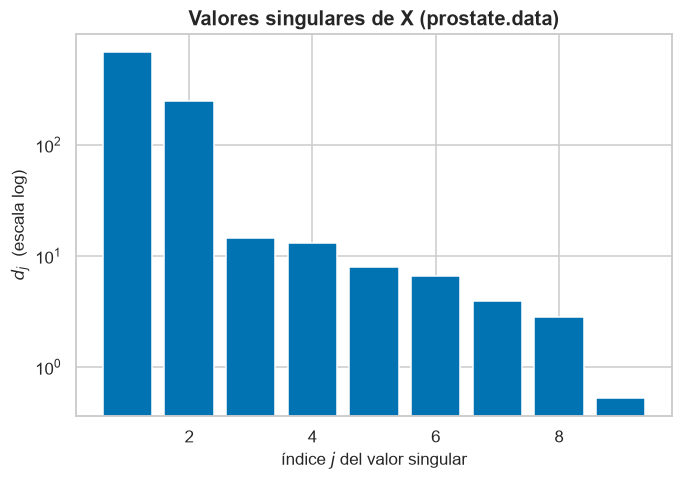

d de prostate.data: [6.92215e+02 2.48811e+02 1.45260e+01 1.32560e+01 8.05400e+00 6.67000e+00
 3.91800e+00 2.83400e+00 5.26000e-01]
cond(X) = 1316.3


In [8]:
# Los valores singulares de la matriz de diseño real (prostate.data) para ver la
# decadencia en un caso real: no son un vector parejo, decaen varios órdenes de
# magnitud entre el primero y el último.
_, d_prostate, _ = np.linalg.svd(X, full_matrices=False)

fig, ax = plt.subplots()
ax.bar(range(1, len(d_prostate) + 1), d_prostate, color=sns.color_palette("colorblind")[0])
ax.set_yscale("log")
ax.set_xlabel("índice $j$ del valor singular")
ax.set_ylabel("$d_j$  (escala log)")
ax.set_title("Valores singulares de X (prostate.data)")
plt.show()

print("d de prostate.data:", d_prostate.round(3))
print("cond(X) =", round(d_prostate.max() / d_prostate.min(), 1))


El gráfico de barras muestra algo que la fórmula sola no transmite tan
rápido: los $d_j$ de una matriz de diseño real no son parecidos entre sí. El
primero es casi 700, el último apenas 0.5 — casi tres órdenes de magnitud de
diferencia. Ese último valor chico (pero no cero) es exactamente el tipo de
"casi rango deficiente" del que habla la §3: ninguno de los predictores del
*Prostate Cancer* es combinación lineal exacta de otro, pero el más débil
está lejos de aportar tanta información independiente como el más fuerte.

### ⚠️ Confusión típica

Confundir **autovalores de $\textbf{X}$** con **valores singulares de
$\textbf{X}$**. Si $\textbf{X}$ no es cuadrada, ni siquiera tiene autovalores. Y
aun cuadrada y simétrica, autovalores y valores singulares coinciden en módulo
pero no en signo: los $d_j$ son siempre $\geq 0$, un autovalor puede ser
negativo. Los valores singulares de $\textbf{X}$ son los autovalores (no
negativos) de $\textbf{X}^T\textbf{X}$, bajo raíz.


## 6. SVD aplicada a regresión lineal

📓 celda 24 · 📕 ESL §3.4.1 · 📘 Bishop §3.1.2

### La idea en criollo

Ahora cobramos lo invertido. Tenemos $\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$
y una descomposición $\textbf{X} = U D V^T$ que hace transparente a
$\textbf{X}^T\textbf{X}$. Metiendo una en la otra, la fórmula de $\hat\beta$ se
simplifica hasta quedar en términos de matrices ortogonales y una diagonal
—cosas fáciles de invertir— y la matriz sombrero se reduce a un simple
$U U^T$.

> **Dónde se rompe la analogía.** "Simplificar" acá no quiere decir "menos
> cuentas para hacer a mano": la SVD de una matriz grande cuesta *más* que
> resolver la ecuación normal directa cuando todo está bien condicionado. Lo que
> comprás con ese costo es **robustez**: la versión con SVD sigue dando una
> respuesta sensata cuando $\textbf{X}^T\textbf{X}$ es singular o casi, que es
> justo cuando la ecuación normal directa falla.

### Formalizándolo

**$\hat\beta$ vía SVD (celda 24).** Arrancamos de la ecuación normal y
reemplazamos usando $\textbf{X}^T\textbf{X} = V D^2 V^T$ (de §5) y
$\textbf{X}^T = V D U^T$. Primero la inversa: como $V$ es ortogonal,

$$(\textbf{X}^T\textbf{X})^{-1} = (V D^2 V^T)^{-1} = (V^T)^{-1} (D^2)^{-1} V^{-1} = V D^{-2} V^T$$

(usando $V^{-1} = V^T$ y que la inversa de una diagonal es la diagonal de los
inversos). Ahora armamos $\hat\beta$:

$$\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y} = \big(V D^{-2} V^T\big)\big(V D U^T\big)\textbf{y} = V D^{-2}\,(V^T V)\,D\,U^T\textbf{y} = V D^{-2} D\, U^T\textbf{y} = V D^{-1} U^T\textbf{y}$$

donde $V^T V = I$ y $D^{-2}D = D^{-1}$. Queda:

$$\boxed{\;\hat\beta = V D^{-1} U^T\,\textbf{y}\;}$$

Sin invertir ninguna matriz "difícil": $U^T$ es transponer, $D^{-1}$ es dividir
por cada $d_j$, $V$ es multiplicar por una matriz ortogonal.

**Cuando $\textbf{X}$ no tiene rango completo.** Si algún $d_j = 0$, no podés
dividir por él: $D^{-1}$ no existe. La salida es la **pseudoinversa** $D^{+}$:
la diagonal donde invertís los $d_j$ no nulos y **dejás en cero** los lugares
donde $d_j = 0$. Con eso,

$$\hat\beta = V D^{+} U^T\,\textbf{y} = \textbf{X}^{+}\textbf{y}$$

y a $\textbf{X}^{+} = V D^{+} U^T$ se la llama **inversa de Moore–Penrose** de
$\textbf{X}$. Entre las infinitas soluciones de mínimos cuadrados que hay cuando
el rango es deficiente (§3), esta elige una en particular: la de **norma
$\|\hat\beta\|$ mínima**. El ejercicio te pide investigar esto y programarlo, así
que hasta acá lo dejo: quedate con que "poner ceros donde $d_j = 0$" y "solución
de norma mínima" son la misma cosa.

**La matriz sombrero se vuelve $U U^T$ (celda 24).** Recordá de la clase 2 §3
que $\hat{\textbf{y}} = \textbf{H}\textbf{y}$ con
$\textbf{H} = \textbf{X}(\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T$. Sustituimos
todo por su SVD, paso a paso:

$$\textbf{H} = \underbrace{(U D V^T)}_{\textbf{X}}\underbrace{(V D^{-2} V^T)}_{(\textbf{X}^T\textbf{X})^{-1}}\underbrace{(V D U^T)}_{\textbf{X}^T} = U D\,(V^T V)\,D^{-2}\,(V^T V)\,D\,U^T = U D D^{-2} D\, U^T = U U^T$$

porque $V^T V = I$ (dos veces) y $D D^{-2} D = D^2 D^{-2} = I$. Entonces:

$$\boxed{\;\textbf{H} = U U^T\;}$$

Esto es lo que la §4 había adelantado: $U U^T$ es el **proyector ortogonal sobre
el espacio columna de $\textbf{X}$**, y proyectar $\textbf{y}$ sobre ese espacio
es exactamente lo que hace $\hat{\textbf{y}}$. Escrita así, dos propiedades de
$\textbf{H}$ que en la clase 2 había que verificar a mano salen de una ojeada:

- **Idempotente:** $\textbf{H}\textbf{H} = (U U^T)(U U^T) = U (U^T U) U^T = U U^T = \textbf{H}$.
  Proyectar dos veces $=$ proyectar una vez.
- **Simétrica:** $(U U^T)^T = U U^T$.
- **Traza $= p+1$:** $\text{tr}(U U^T) = \text{tr}(U^T U) = \text{tr}(I_{p+1}) = p+1$.
  Es el número que usamos en §2 para explicar el $N - p - 1$ del estimador
  insesgado de $\sigma^2$.

### ¿Por qué nos importa?

Porque cierra el círculo de la clase. La §3 planteó el problema (multicolinealidad,
rango deficiente); la SVD lo diagnostica (mirás los $d_j$ chicos) y lo resuelve
(pseudoinversa). Y de paso te reescribe objetos que ya conocías —$\hat\beta$, la
matriz sombrero, la traza que aparece en $\hat\sigma^2$— de una forma donde sus
propiedades son evidentes en vez de cuentas. La próxima clase (Ridge, ESL §3.4)
usa esta **misma** descomposición para mostrar qué le hace exactamente la
penalización a cada dirección $d_j$.


In [9]:
X_ver = np.column_stack([np.ones(80), rng.normal(size=(80, 3))])
y_ver = X_ver @ np.array([1., 2., -1., 0.5]) + rng.normal(scale=0.3, size=80)

Uv, dv, Vtv = np.linalg.svd(X_ver, full_matrices=False)

beta_svd = Vtv.T @ ((Uv.T @ y_ver) / dv)          # V D^-1 U^T y   (dividir por d = aplicar D^-1)
beta_ref, *_ = np.linalg.lstsq(X_ver, y_ver, rcond=None)
print("beta_svd == lstsq:", np.allclose(beta_svd, beta_ref))

H_svd = Uv @ Uv.T
H_dir = X_ver @ np.linalg.inv(X_ver.T @ X_ver) @ X_ver.T
print("H_svd == H_dir:   ", np.allclose(H_svd, H_dir))
print("tr(H_svd) =", round(np.trace(H_svd), 6), " ≈ p+1 =", X_ver.shape[1])


beta_svd == lstsq: True
H_svd == H_dir:    True
tr(H_svd) = 4.0  ≈ p+1 = 4


`(Uv.T @ y_ver) / dv` es la forma vectorizada de $D^{-1}U^T\textbf{y}$: como $D$
es diagonal, multiplicar por $D^{-1}$ es dividir componente a componente por el
vector `d`. Si algún `d[j]` fuera casi cero, ahí verías el problema de la §3 en
vivo: esa componente se dispara.

#### 🏭 Así se hace en la industria

La cuenta de arriba usa datos sintéticos para verificar la fórmula. En la
práctica no armás $U$, $D$, $V$ a mano: le pasás la matriz a la librería y listo.
Repitamos el estimador $\hat\beta = V D^{-1} U^T \textbf{y}$ sobre el dataset
real de *Prostate Cancer* — el mismo `X`, `y` de §1 — y comparémoslo con
`sklearn`, que es la forma en que esto se resuelve fuera de una clase de
álgebra lineal.


In [10]:
from sklearn.linear_model import LinearRegression

# SVD "a mano" sobre los datos reales, reusando U, d, Vt calculados en §5 para X.
U_p, d_p, Vt_p = np.linalg.svd(X, full_matrices=False)
beta_svd_prostate = Vt_p.T @ ((U_p.T @ y) / d_p)

# La forma en que se resuelve en la práctica: sklearn agrega el intercepto solo,
# así que se lo pasamos sin la columna de 1s.
modelo = LinearRegression().fit(X[:, 1:], y)
beta_sklearn = np.concatenate([[modelo.intercept_], modelo.coef_])

print("beta (SVD a mano):", beta_svd_prostate.round(4))
print("beta (sklearn):   ", beta_sklearn.round(4))
print("coinciden:", np.allclose(beta_svd_prostate, beta_sklearn))


beta (SVD a mano): [ 0.1816  0.5643  0.622  -0.0212  0.0967  0.7617 -0.1061  0.0492  0.0045]
beta (sklearn):    [ 0.1816  0.5643  0.622  -0.0212  0.0967  0.7617 -0.1061  0.0492  0.0045]
coinciden: True


Coinciden hasta el redondeo: `LinearRegression` de `sklearn` no usa magia
propia, resuelve el mismo problema de mínimos cuadrados por dentro (vía una
factorización tipo SVD/QR sobre $\textbf{X}$, la misma razón de la §5 por la
que no se arma $\textbf{X}^T\textbf{X}$). La ventaja de la versión de librería
no es el resultado —ya viste que es idéntico— sino la API: en un pipeline real
no vas a estar armando `U, d, Vt` a mano cada vez, vas a llamar `.fit()`. Pero
cuando algo te da un resultado raro (coeficientes gigantes, por ejemplo), saber
qué hay *adentro* de ese `.fit()` es lo que te permite diagnosticar si el
problema es multicolinealidad — y ahora ya sabés dónde mirar: el vector `d_p`
de arriba.

### ⚠️ Confusión típica

Escribir `Vt @ ...` en lugar de `Vt.T @ ...`. `np.linalg.svd` devuelve $V^T$,
así que la fórmula $\hat\beta = V D^{-1} U^T\textbf{y}$ se programa con `Vt.T`
(que es $V$). Es el error más común al pasar esta cuenta a código.

Segunda: creer que $\hat\beta = V D^{-1} U^T\textbf{y}$ y
$\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$ son "dos
estimadores". Son la **misma** fórmula, con rango completo dan el **mismo**
número. La SVD solo la reescribe de forma numéricamente más estable, y —con
$D^{+}$ en lugar de $D^{-1}$— la extiende al caso sin rango completo, donde la
otra directamente no está definida.


## 🧵 El hilo conductor

La clase 2 (`2_regresion_lineal_cuadrados_minimos.ipynb`) terminó con una fórmula
cerrada, $\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$, y una
advertencia dicha al pasar: todo esto vale "*mientras $\textbf{X}$ tenga rango
completo*". Esta clase agarra esa advertencia y la exprime.

Primero, un rodeo que resulta no serlo. **Máxima verosimilitud** (§2) parece un
método rival de cuadrados mínimos, pero bajo el supuesto de ruido gaussiano iid
llega al mismo $\hat\beta$, con la misma fórmula. Lo que agrega es una
estimación de $\sigma^2$ —y ahí aparece, ahora derivado y no postulado, el
famoso $N - p - 1$ del denominador—. La moraleja conceptual: cuadrados mínimos
no era una elección arbitraria, era la respuesta óptima si creés que el error
es normal.

Después, el problema de fondo. La celda 8, una sola línea, pregunta qué pasa
cuando $\textbf{X}$ no tiene rango completo, o casi. La respuesta (§3): se
pierde la unicidad de $\hat\beta$, o —peor y más común— el $\hat\beta$ que
existe se vuelve numéricamente inestable. Eso motiva toda la segunda mitad.

La **SVD** (§4, §5) es la herramienta. Descompone cualquier $\textbf{X}$ en
rotar–escalar–rotar, y los valores singulares $d_j$ ponen un número sobre "qué
tan cerca de colapsar" está cada dirección de los datos — lo vimos con números
reales en el gráfico de barras de §5. Con esa descomposición en la mano (§6),
$\hat\beta$ se reescribe como $V D^{-1} U^T\textbf{y}$ —estable— y, cuando hay
rango deficiente, como $V D^{+} U^T\textbf{y}$, la pseudoinversa de
Moore–Penrose, que elige la solución de norma mínima. La matriz sombrero se
revela como $U U^T$, y su traza $p+1$ conecta de vuelta con el $\hat\sigma^2$
de §2. Y en la celda de "así se hace en la industria" viste que `sklearn` no
hace magia distinta: resuelve el mismo problema.

Hacia adelante: la próxima clase es regularización (Ridge, Lasso; ESL §3.4).
Ridge le suma $\lambda I$ a $\textbf{X}^T\textbf{X}$ antes de invertir, lo que en
términos de SVD equivale a reemplazar cada $1/d_j$ por $d_j/(d_j^2 + \lambda)$:
las direcciones con $d_j$ grande casi no se tocan, las de $d_j$ chico se
frenan. Vas a reconocer cada pieza de esta clase en esa.

## ✅ Autoevaluación

**1.** ¿Por qué, bajo errores normales iid, maximizar la verosimilitud respecto
de $\beta$ da el mismo $\hat\beta$ que cuadrados mínimos?

<details><summary>Respuesta</summary>

Porque en la log-verosimilitud
$-\tfrac{N}{2}\log(2\pi) - N\log\sigma - \tfrac{1}{2\sigma^2}(\textbf{y}-\textbf{X}\beta)^T(\textbf{y}-\textbf{X}\beta)$,
los dos primeros términos no dependen de $\beta$. El tercero es
$-\tfrac{1}{2\sigma^2}$ (una constante **negativa**, porque $\sigma^2 > 0$) por
$RSS(\beta)$. Maximizar "menos una constante positiva por $RSS$" es idéntico a
minimizar $RSS$. Así que el $\arg\max$ en $\beta$ de la verosimilitud es el
$\arg\min$ de $RSS$, que es $(\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$.

</details>

**2.** ¿Qué te da máxima verosimilitud que cuadrados mínimos, por sí solo, no
da?

<details><summary>Respuesta</summary>

Dos cosas. Una estimación de la varianza del ruido,
$\hat\sigma^2_{\text{MV}} = \tfrac{1}{N}(\textbf{y}-\textbf{X}\hat\beta)^T(\textbf{y}-\textbf{X}\hat\beta)$,
que sale de maximizar la verosimilitud respecto de $\sigma$. Y un marco
probabilístico (el error tiene una distribución con nombre) que se generaliza a
modelos sin solución cerrada —regresión logística, GLM— donde cuadrados mínimos
ni siquiera se plantea. Para $\beta$ en el modelo lineal, en cambio, no agrega
nada: da lo mismo.

</details>

**3.** Mostrá que maximizar la log-verosimilitud respecto de $\sigma$, con
$\hat\beta$ ya fijo, da $\hat\sigma^2 = S/N$ con $S = RSS(\hat\beta)$.

<details><summary>Respuesta</summary>

Con $\hat\beta$ fijo, $\ell(\sigma) = \text{cte} - N\log\sigma - \tfrac{S}{2\sigma^2}$.
Derivando: $\ell'(\sigma) = -\tfrac{N}{\sigma} + \tfrac{S}{\sigma^3}$ (la
segunda derivada usa $\tfrac{d}{d\sigma}\sigma^{-2} = -2\sigma^{-3}$). Igualando
a cero y multiplicando por $\sigma^3 > 0$: $-N\sigma^2 + S = 0$, o sea
$\sigma^2 = S/N$. Es un máximo: $\ell''(\sigma) = \tfrac{N}{\sigma^2} - \tfrac{3S}{\sigma^4}$,
que en $\sigma^2 = S/N$ vale $\tfrac{N^2}{S} - \tfrac{3N^2}{S} = -\tfrac{2N^2}{S} < 0$.

</details>

**4.** El estimador $\hat\sigma^2_{\text{MV}} = S/N$ es sesgado. ¿Hacia qué lado
y por qué?

<details><summary>Respuesta</summary>

Subestima: $E[\hat\sigma^2_{\text{MV}}] = \tfrac{N-p-1}{N}\sigma^2 < \sigma^2$.
El motivo es que $E[S] = (N-p-1)\sigma^2$, no $N\sigma^2$: el residuo es
$(I-\textbf{H})\epsilon$, y $E[\epsilon^T(I-\textbf{H})\epsilon] = \sigma^2\,\text{tr}(I-\textbf{H}) = \sigma^2(N - \text{tr}\,\textbf{H}) = \sigma^2(N-p-1)$,
porque $\text{tr}\,\textbf{H} = p+1$. Intuitivamente: la $RSS$ se calcula con el
$\hat\beta$ que la **minimiza** en esa muestra, así que sale sistemáticamente
más chica que la que daría el $\beta$ verdadero. Dividir por $N-p-1$ corrige
ese factor.

</details>

**5.** Dada la SVD *thin* $\textbf{X} = U D V^T$, probá que
$\textbf{X}^T\textbf{X} = V D^2 V^T$ y explicá qué son entonces los valores
singulares en términos de $\textbf{X}^T\textbf{X}$.

<details><summary>Respuesta</summary>

$\textbf{X}^T\textbf{X} = (U D V^T)^T(U D V^T) = V D^T U^T U D V^T = V D (U^T U) D V^T = V D^2 V^T$,
usando $(ABC)^T = C^TB^TA^T$, $D^T = D$ (diagonal) y $U^T U = I$. Como $V$ es
ortogonal y $D^2$ diagonal, $V D^2 V^T$ es una descomposición en autovectores de
$\textbf{X}^T\textbf{X}$: las columnas de $V$ son sus autovectores y los $d_j^2$
sus autovalores. Entonces los valores singulares son
$d_j = \sqrt{\lambda_j}$, con $\lambda_j$ los autovalores de
$\textbf{X}^T\textbf{X}$ (que son $\geq 0$ porque
$w^T\textbf{X}^T\textbf{X}w = \|\textbf{X}w\|^2 \geq 0$).

</details>

**6.** Tenés $\textbf{X}$ de $100 \times 4$ con columnas independientes y le
agregás una quinta columna igual a la suma de la 2ª y la 3ª. ¿Qué pasa con los
valores singulares? ¿Y con $\hat\beta = V D^{-1} U^T\textbf{y}$?

<details><summary>Respuesta</summary>

La nueva $\textbf{X}$ es $100 \times 5$ pero de rango 4: hay un vector $v \neq 0$
(el que combina esas columnas) con $\textbf{X}v = 0$. Entonces uno de los cinco
valores singulares es **exactamente 0** ($d_5 = 0$). La fórmula
$\hat\beta = V D^{-1} U^T\textbf{y}$ deja de estar definida, porque $D^{-1}$
pide dividir por $d_5 = 0$. Hay que pasar a la pseudoinversa $D^{+}$ (invertir
los $d_j \neq 0$, dejar 0 donde $d_j = 0$), que da la solución de mínimos
cuadrados de norma mínima. En datos reales el $d_5$ no sería 0 exacto sino
diminuto, y $\hat\beta$ existiría pero con varianza enorme.

</details>

**7.** ¿Por qué los algoritmos numéricos calculan la SVD trabajando sobre
$\textbf{X}$ y no diagonalizando $\textbf{X}^T\textbf{X}$, si esa segunda cuenta
"funciona" en el papel?

<details><summary>Respuesta</summary>

Por dos razones. Tamaño: $\textbf{X}\textbf{X}^T$ es $N \times N$ (inmanejable
con $N$ grande), y aunque uses $\textbf{X}^T\textbf{X}$ ($p \times p$), formar
ese producto cuesta. Precisión: $\kappa(\textbf{X}^T\textbf{X}) = \kappa(\textbf{X})^2$,
el número de condición se **eleva al cuadrado**. En problemas con
multicolinealidad ($d_p$ ya chico), eso destruye precisión justo donde más la
necesitás. Trabajar sobre $\textbf{X}$ directo (vía factorizaciones tipo QR o
bidiagonalización) evita las dos cosas.

</details>

**8.** Probá que $\textbf{H} = \textbf{X}(\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T = U U^T$
usando la SVD, y explicá por qué así es obvio que $\textbf{H}$ es idempotente.

<details><summary>Respuesta</summary>

$\textbf{H} = (U D V^T)(V D^{-2} V^T)(V D U^T)$. Agrupando:
$U D (V^T V) D^{-2} (V^T V) D U^T = U D\,I\,D^{-2}\,I\,D\,U^T = U (D D^{-2} D) U^T = U (D^2 D^{-2}) U^T = U U^T$.
Idempotencia: $\textbf{H}\textbf{H} = (U U^T)(U U^T) = U (U^T U) U^T = U\,I\,U^T = U U^T = \textbf{H}$,
usando $U^T U = I$. Proyectar dos veces sobre el espacio columna de $\textbf{X}$
es lo mismo que proyectar una.

</details>

**9.** En la SVD *thin* con $N > p$ vale $U^T U = I$ pero $U U^T \neq I$.
¿Cómo puede ser? ¿Qué es $U U^T$ entonces?

<details><summary>Respuesta</summary>

$U$ es $N \times p$ con $N > p$: tiene $p$ columnas ortonormales, pero esas $p$
columnas no pueden ser base de todo $\mathbb{R}^N$ (hacen falta $N$). $U^T U$ es
$p \times p$ y da $I_p$ (las columnas son ortonormales entre sí). $U U^T$ es
$N \times N$ y **no** puede ser $I_N$ porque tiene rango $p < N$. Lo que es:
el **proyector ortogonal sobre el subespacio de $\mathbb{R}^N$ generado por las
columnas de $U$** (que es el espacio columna de $\textbf{X}$). Aplica $I$ a los
vectores que ya están en ese subespacio y aniquila la componente perpendicular.

</details>

**10.** ¿Qué relación hay entre quedarse con los $t$ mayores valores singulares
(*truncated SVD*) y el problema de multicolinealidad de la §3?

<details><summary>Respuesta</summary>

La multicolinealidad se manifiesta como valores singulares chicos: direcciones
de los datos casi colapsadas, cuyo $1/d_j$ en $\hat\beta = V D^{-1} U^T\textbf{y}$
amplifica ruido. *Truncar* —descartar los $d_j$ por debajo de un umbral, como
hace la pseudoinversa con los exactamente nulos— saca de la cuenta esas
direcciones inestables. Perdés algo de ajuste (ya no reconstruís $\textbf{X}$
exacta) a cambio de un $\hat\beta$ mucho más estable. Es la misma idea que
regularizar, y el ejercicio te pide implementarla; regresión por componentes
principales (ESL §3.5) es exactamente esto.

</details>

## 🎯 Centros para los ejercicios

### Ejercicio 1 — Cuadrados mínimos con SVD y multicolinealidad en *Prostate Cancer*

- **De qué va realmente:** usar la SVD como herramienta numérica para resolver
  OLS, y después provocar multicolinealidad a propósito para ver en vivo el
  fenómeno de la §3: los coeficientes se vuelven basura, los valores singulares
  te avisan (uno se va a cero), pero las predicciones casi no se enteran. El
  cierre es la pseudoinversa de Moore–Penrose como forma de recuperar un
  $\hat\beta$ sensato, y entender qué hace `sklearn` por dentro.
- **Por dónde arrancar:** reutilizá el `X` (con columna de 1s) y el `y` del
  bloque "En código" de §1. Para el punto 1,
  `U, d, Vt = np.linalg.svd(X, full_matrices=False)` y armá
  $\hat\beta = V D^{-1} U^T\textbf{y}$ como `Vt.T @ ((U.T @ y) / d)` (ojo:
  `Vt` ya es $V^T$, y dividir por `d` es aplicar $D^{-1}$). Comparalo contra tu
  OLS de la clase 2.
- **Con qué chequear:** con los 8 predictores originales, tu $\hat\beta$ por SVD
  tiene que coincidir (salvo redondeo) con `np.linalg.lstsq` y con la
  **Tabla 3.2 de ESL** — la celda de §6 ya te lo muestra funcionando contra
  `sklearn`. Al agregar la columna colineal del punto 2: mirá el vector `d`
  —el valor singular más chico cae varios órdenes de magnitud— y la norma
  $\|\hat\beta\|$ —se dispara—, mientras que `X @ beta` casi no cambia.
  Para el punto 3, tu estimador con pseudoinversa (`np.linalg.pinv`, o `D^+` a
  mano) tiene que dar la solución de **norma mínima**: verificá que
  $\|\hat\beta_{\text{pinv}}\| \leq \|\hat\beta\|$ de cualquier otra solución que
  construyas sumándole un vector del núcleo.
- **⚠️ Dónde te vas a trabar:** en el punto 3, en fijar el umbral por debajo del
  cual un $d_j$ "cuenta como cero" (el parámetro `rcond`): muy chico y seguís
  arrastrando la dirección inestable, muy grande y tirás información buena. Y en
  el punto 4, en explicar *por qué* `sklearn` coincide con una de tus versiones
  y no con la otra: la pista está en qué descomposición usa `LinearRegression`
  internamente (la misma discusión del final de §5 sobre por qué no se forma
  $\textbf{X}^T\textbf{X}$) — pero eso te toca investigarlo a vos, igual que el
  Ejercicio 5 de la clase 2.
